In [1]:
import math
from matplotlib import pyplot as plt
import random

## Replacements within (list of) strings

1) Write a function remove_umlaut(word) that gets a string, e.g. word='würde', as an input 
   and replaces every umlaut ä, ö, ü by ae, oe, ue, respectively. 
   Hint: You can use the method .replace() on string objects.
2) Use a for loop to change all words within the following list 
   words = ['bäume', 'träume', 'öde', 'schön', 'türen']
3) Load the text file text_example.txt and remove every umlaut. 
   For opening textfiles, use text = open(file.txt). By text.read(), you obtain the whole text as a string.

In [2]:
def remove_umlaut(word):
    word = word.replace('ä', 'ae')
    word = word.replace('ö', 'oe')
    word = word.replace('ü', 'ue')
    word = word.replace('Ä', 'Ae')
    word = word.replace('Ö', 'Oe')
    word = word.replace('Ü', 'Ue')
    return word

print(remove_umlaut('würde'))

words = ['bäume', 'träume', 'öde', 'schön', 'türen']
for i in range(len(words)):
    words[i] = remove_umlaut(words[i])
print(words)

text = open('/home/s_e8mv8u/Desktop/Lecture-DL-for-PDEs/Introduction to Python/text_example.txt')
text = text.read()
print(text)
text = remove_umlaut(text)
print(text)

wuerde
['baeume', 'traeume', 'oede', 'schoen', 'tueren']
Fünf fröhliche Bären mögen süße Äpfel und köstlichen Käse. Überall hören sie Geräusche, während sie gemütlich durch grüne Wälder laufen. Plötzlich stößt ein wütender Löwe hinzu, brüllt laut und stört die Idylle. Die Bären flüchten schnell über Hügel und durch Höhlen, bis schließlich Ruhe einkehrt.
Fuenf froehliche Baeren moegen sueße Aepfel und koestlichen Kaese. Ueberall hoeren sie Geraeusche, waehrend sie gemuetlich durch gruene Waelder laufen. Ploetzlich stoeßt ein wuetender Loewe hinzu, bruellt laut und stoert die Idylle. Die Baeren fluechten schnell ueber Huegel und durch Hoehlen, bis schließlich Ruhe einkehrt.


## Numerical Integration
- Define a method integral(func, x0, x1, N=100) that approximates the integral of the function func from x0 to x1 according to the following formula:
$$
\int_{x_0}^{x_1} f(x) dx \approx \frac{x_1-x_0}{N} \sum_{k=0}^{N-1} f\left(x_0 + \frac{k}{N}(x_1-x_0)\right)
$$
- Define a method f(x) returning the cosine of x. Estimate $\int_0^{\pi} f(x) dx$
- Plot the function $x\mapsto \int_0^x f(y) dy$ using your integral method. For that, create a list of equidistant x-values within $[0, 2\pi]$. Compare to $F(x)=\sin(x)$. 

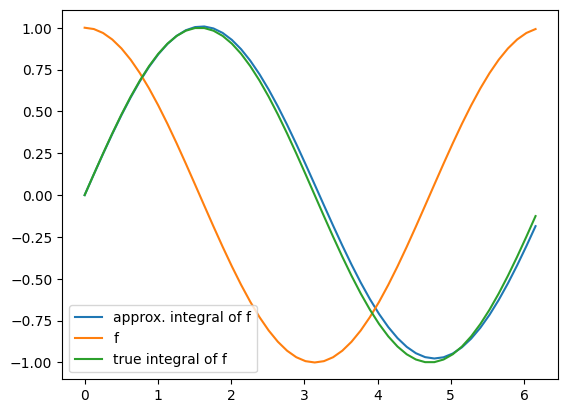

In [3]:
def f(x):
    return math.cos(x)

def integral(func, x0, x1, N=100):
    cum_sum = 0
    h = (x1-x0)/N
    for k in range(N-1):
        cum_sum = cum_sum + func(x0 + h*k)
    return cum_sum * h

xs = [2*math.pi*i/50 for i in range(50)]
fs = [f(x) for x in xs]
fs_int = [integral(f, 0, x, 100) for x in xs]
true_fs_int = [math.sin(x) for x in xs]

plt.plot(xs, fs_int, label='approx. integral of f')
plt.plot(xs, fs, label='f')
plt.plot(xs, true_fs_int, label='true integral of f')
plt.legend()
plt.show()

## Fibonacci numbers
- Create a method based on a for-loop, which computes the n. Fibonacci number for given start values $x_0$, $x_1$. 
  Recall that the next Fibonacci number is calculated via $x_k = x_{k-1} + x_{k-2}$
- Another way: Write a recursive method for calculating the n. Fibonacci number.
  This means that the method calls itself for smaller n-values 

In [4]:
def fibo_for_loop(n, x0=1, x1=1):
    if n==1: return x0
    elif n==2: return x1
    current = x1 # Startwerte
    previous = x0
    for i in range(n-2):
        intermediate = current + previous # next fibonacci number
        previous = current 
        current = intermediate
    return current

def fibo_recursive(n, x0=1, x1=1):
    if n==1: return x0
    elif n==2: return x1
    else: return fibo_recursive(n-1, x0=x0, x1=x1) + fibo_recursive(n-2, x0=x0, x1=x1)
    
for i in range(1, 10):
    print(fibo_for_loop(i, x0=1, x1=1), fibo_recursive(i, x0=1, x1=1))


1 1
1 1
2 2
3 3
5 5
8 8
13 13
21 21
34 34


## 1D-Random Walks
Implement a class BernoulliWalk, which has the following attributes
- self.paths: A list that cointains lists of points that have been visited during a walk
- self.p: Value between 0 and 1, probability for moving by +1 at a single step during the walk() method.

and methods:
- walk(self, start:float, n:int): for given start point $\in \R$, it computes the next n "visited points" by the following update rule: move from the previous point to the next point by adding +1 with probability self.p and adding -1 with probability 1-self.p. 
Finally, all thereby visited points are collected within a list and this list is appended to self.paths.
Hint: Use random.random() for drawing a number within [0,1] from a uniform distribution.
- plot_paths(self): plots every path in self.paths using pyplot.plot(...) from matplotlib. If no paths have been generated yet, just print an information about that.


In [5]:
class BernoulliWalk():
    def __init__(self, p): # maybe input continuous time?
        self.paths = []
        self.p = p
        
    def plot_paths(self):
        if len(self.paths) == 0:
            print('You have not walked yet...')
        else:
            for path in self.paths:
                plt.plot(path)
            plt.show()
        
    def walk(self, start, n):
        visited_points = [start]
        for _ in range(n):
            next_point = self.single_step(visited_points)
            visited_points.append(next_point)
        self.paths.append(visited_points)

    def single_step(self, visited_points):
        x = random.random()
        if x < self.p: step=1
        else: step= -1
        return visited_points[-1] + step

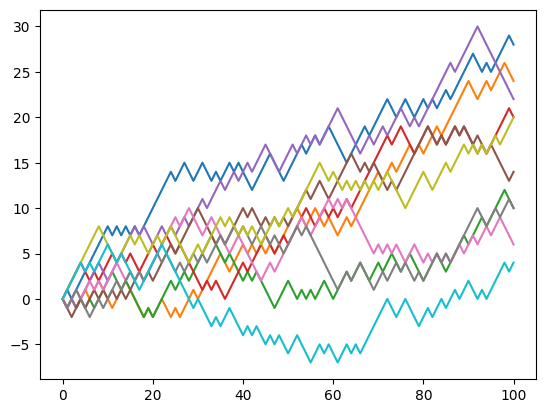

In [6]:
# Implement the class BernoulliWalk such that the code below will plot 10 Bernoulli random walks, each making 100 random +/- 1 steps
b = BernoulliWalk(p=0.6)
for _ in range(10):
    b.walk(start=0, n=100)
b.plot_paths()

TODO: Create a class GaussianWalk in a similar way. Instead of self.p, it has the attributes self.mean and self.std.
The update rule within its walk() function is as follows: move from the previous point $\in \R$ to the next point by a number "step" which has been drawn from a gaussian distribution with mean value self.mean and standard deviation self.std. Hint: Use random.gauss(...).

In [7]:
class GaussianWalk():
    def __init__(self, mean=0, std=1): # maybe input continuous time?
        self.paths = []
        self.mean = mean
        self.std = std
        
    def plot_paths(self):
        if len(self.paths) == 0:
            print('You have not walked yet...')
        else:
            for path in self.paths:
                plt.plot(path)
            plt.show()
        
    def walk(self, start, n):
        visited_points = [start]
        for _ in range(n):
            next_point = self.single_step(visited_points)
            visited_points.append(next_point)
        self.paths.append(visited_points)

    def single_step(self, visited_points):
        step = random.gauss(self.mean, self.std)
        return visited_points[-1] + step

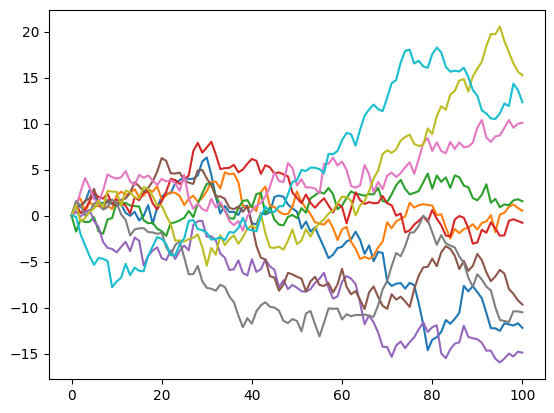

In [8]:
g = GaussianWalk(mean=0, std=1)
for _ in range(10):
    g.walk(start=0, n=100)
g.plot_paths()

TODO: Some functionalities within BernoulliWalk and GaussianWalk are the same. Write a class RandomWalk, from which both classes inherit. 
By that, try to reduce amount of code that occurs multiple times within the subclasses.

In [9]:
class RandomWalk():
    def __init__(self): # maybe input continuous time?
        self.paths = []

    def plot_paths(self):
        if len(self.paths) == 0:
            print('You have not walked yet...')
        else:
            for path in self.paths:
                plt.plot(path)
            plt.show()
        
    def walk(self, start, n):
        visited_points = [start]
        for _ in range(n):
            next_point = self.single_step(visited_points)
            visited_points.append(next_point)
        self.paths.append(visited_points)

    def single_step(self, x):
        raise NotImplementedError("Subclasses must implement the 'single_step' method for being able to walk!")
        
class BernoulliWalk(RandomWalk):
    def __init__(self, p = 0.5):
        super().__init__()
        self.p = p

    def single_step(self, visited_points):
        x = random.random()
        if x < self.p: step=1
        else: step= -1
        return visited_points[-1] + step

class GaussianWalk(RandomWalk):
    def __init__(self, mean=0, std=1):
        super().__init__()
        self.mean = mean
        self.std = std

    def single_step(self, visited_points):
        return visited_points[-1] + random.gauss(self.mean, self.std)

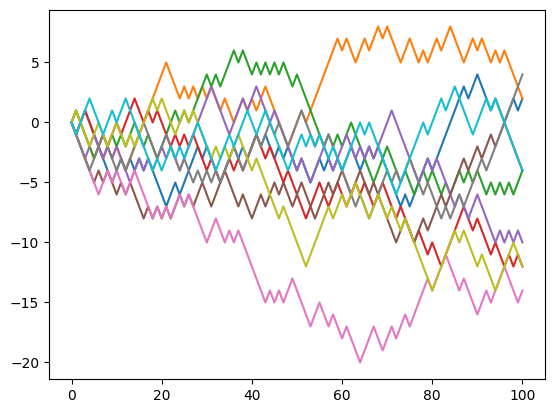

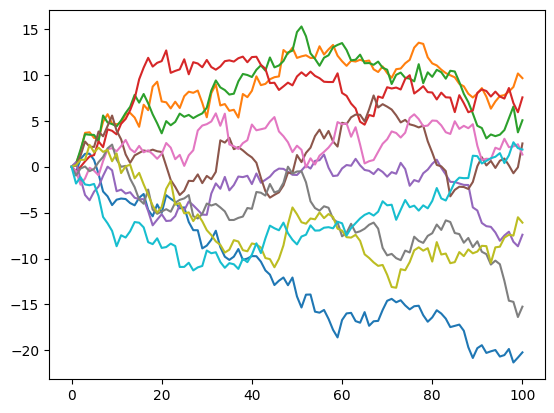

In [10]:
b = BernoulliWalk(p=0.5)
for _ in range(10):
    b.walk(start=0, n=100)
b.plot_paths()

g = GaussianWalk(mean=0, std=1)
for _ in range(10):
    g.walk(start=0, n=100)
g.plot_paths()

### Bonus: 
Adapt the classes above, such that they can perform random walks in two-dimensions.
- E.g., include an attribute self.dimension, which can be used within plot_paths() to distinguish between 1D and 2D plots 

In [11]:
class RandomWalk():
    def __init__(self):
        self.paths = []
        self.dimension = None

    def plot_paths(self):
        if len(self.paths) == 0:
            print('You have not walked yet...')
        else:
            if self.dimension == 1:
                for path in self.paths:
                    plt.plot(path)
            elif self.dimension == 2:
                for path in self.paths:
                    x, y = zip(*path) # unpacks x,y coordinates
                    plt.plot(x, y, marker='o', markersize=3)
            plt.show()
        
    def walk(self, start, n):
        visited_points = [start]
        for _ in range(n):
            next_point = self.single_step(visited_points)
            visited_points.append(next_point)
        self.paths.append(visited_points)

    def single_step(self, x):
        raise NotImplementedError("Subclasses must implement the 'single_step' method")

In [12]:
class GaussianWalk1D(RandomWalk):
    def __init__(self, mean=0, std=1):
        super().__init__()
        self.mean = mean
        self.std = std
        self.dimension=1

    def single_step(self, visited_points):
        return visited_points[-1] + random.gauss(self.mean, self.std)

class GaussianWalk2D(RandomWalk):
    def __init__(self, mean=0, std=1):
        super().__init__()
        self.mean = mean
        self.std = std
        self.dimension=2

    def single_step(self, visited_points):
        start = visited_points[-1]
        x = start[0] + random.gauss(self.mean, self.std)
        y = start[1] + random.gauss(self.mean, self.std)
        return (x,y)

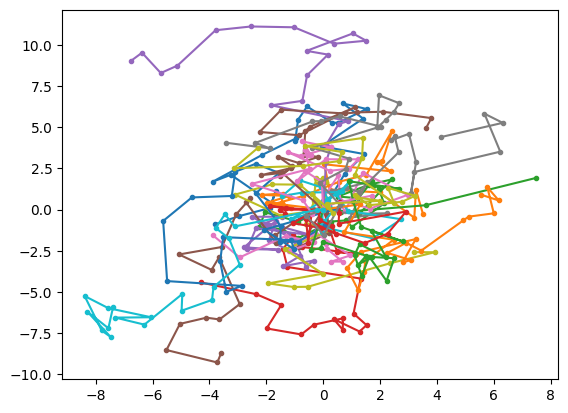

In [13]:
g2 = GaussianWalk2D()
for i in range(20):
    g2.walk(start=(0,0), n=20)
g2.plot_paths()

In [14]:
# Just for fun: at each walk, the start point is randomly chosen. The walk is then along a spiral of random size.
class SpiralWalk(RandomWalk):
    def __init__(self):
        super().__init__()
        self.dimension = 2
        self.h = 0 # at each walk, the size h of the spiral is randomly set to a new value
            
    def spiral(self, t): # parameterization of a spiral
        return self.h*t*math.cos(t), self.h*t*math.sin(t)

    def single_step(self, visited_points):
        t = len(visited_points)
        start = visited_points[0]
        x, y = self.spiral(t)
        return (start[0] + x, start[1] + y)

    # New walk function, as the walk function in the super class needs a start value, which we want to set randomly here...
    def walk(self, n):
        start = (random.randint(-10, 10), random.randint(-10, 10))
        self.h = (random.random()-0.5) / 5
        return super().walk(start, n) # calls the walk() method of the super class RandomWalk

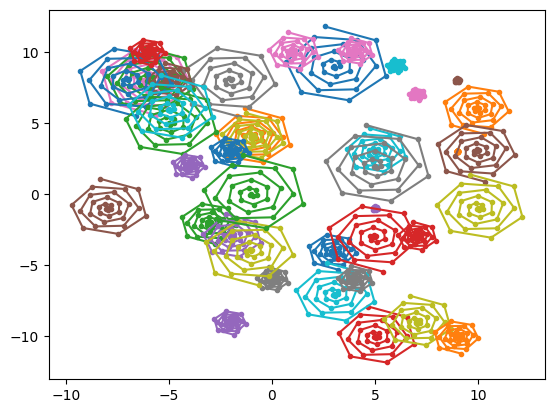

In [15]:
s = SpiralWalk()
for _ in range(40):
    s.walk(30)
s.plot_paths()